# 06 — Visualisations: Gantt Charts & Convergence

**Goal**: Produce dissertation-ready figures comparing SPT, GA, and Hybrid schedules.

Topics:
1. Gantt chart: SPT vs Hybrid on same instance (side-by-side)
2. Convergence plot: GA vs Hybrid fitness over generations

In [1]:
import sys, os
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import seaborn as sns
from collections import Counter
from src.instance_generator import generate_instance
from src.heuristics import spt
from src.evaluator import evaluate
from src.ga import run_ga
from src.drl_agent import run_hybrid
from stable_baselines3 import PPO

sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
print("✓ Imports complete")

✓ Imports complete


## 1. Generate Instance & Run Methods

In [2]:
# Use medium_2m, seed=0 for representative visualisation
inst = generate_instance(n=20, m=2, seed=0)
print(f"Instance: n={inst['n']}, m={inst['m']}")
print(f"  proc_times: {inst['proc_times']}")
print(f"  colour_ids: {inst['colour_ids']}")

# Run SPT
spt_sigma = spt(inst)
spt_result = evaluate(spt_sigma, inst, alpha=0.5)
print(f"\nSPT: composite={spt_result['composite']:.3f}, tardiness={spt_result['weighted_tardiness']:.1f}, setup={spt_result['setup_cost']:.1f}")

# Run GA (200 gens, seed=0)
print("\nRunning GA (200 generations)...")
ga_result = run_ga(inst, n_gen=200, pop_size=100, seed=0, verbose=False)
print(f"GA:  composite={ga_result['best_fitness']:.3f}, tardiness={ga_result['weighted_tardiness']:.1f}, setup={ga_result['setup_cost']:.1f}")

# Run Hybrid (requires trained model)
model_path = os.path.join(root, "models", "ppo_hyperheuristic")
if os.path.exists(model_path + ".zip"):
    model = PPO.load(model_path)
    hybrid_result = run_hybrid(inst, model, seed=0)
    print(f"Hybrid: composite={hybrid_result['composite']:.3f}, tardiness={hybrid_result['weighted_tardiness']:.1f}, setup={hybrid_result['setup_cost']:.1f}")
else:
    print("⚠ No trained model found. Run experiments/train_ppo.py first.")
    hybrid_result = None

Instance: n=20, m=2
  proc_times: [27. 21. 18. 12. 13.  6.  6.  5.  9. 26. 21. 28. 18. 20. 30. 23. 21. 19.
 19. 29.]
  colour_ids: [1 5 4 0 2 6 3 0 5 5 5 1 0 6 0 3 0 2 3 2]

SPT: composite=0.110, tardiness=0.0, setup=260.0

Running GA (200 generations)...
GA:  composite=0.011, tardiness=51.9, setup=12.4


/home/dopedino/miniforge3/envs/dissertation/lib/python3.11/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/dopedino/miniforge3/envs/dissertation/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Hybrid: composite=0.008, tardiness=25.5, setup=11.7


## 2. Gantt Chart: SPT vs Hybrid

Side-by-side Gantt charts. Each job coloured by colour_id. Setup transitions shown as hatched gaps.

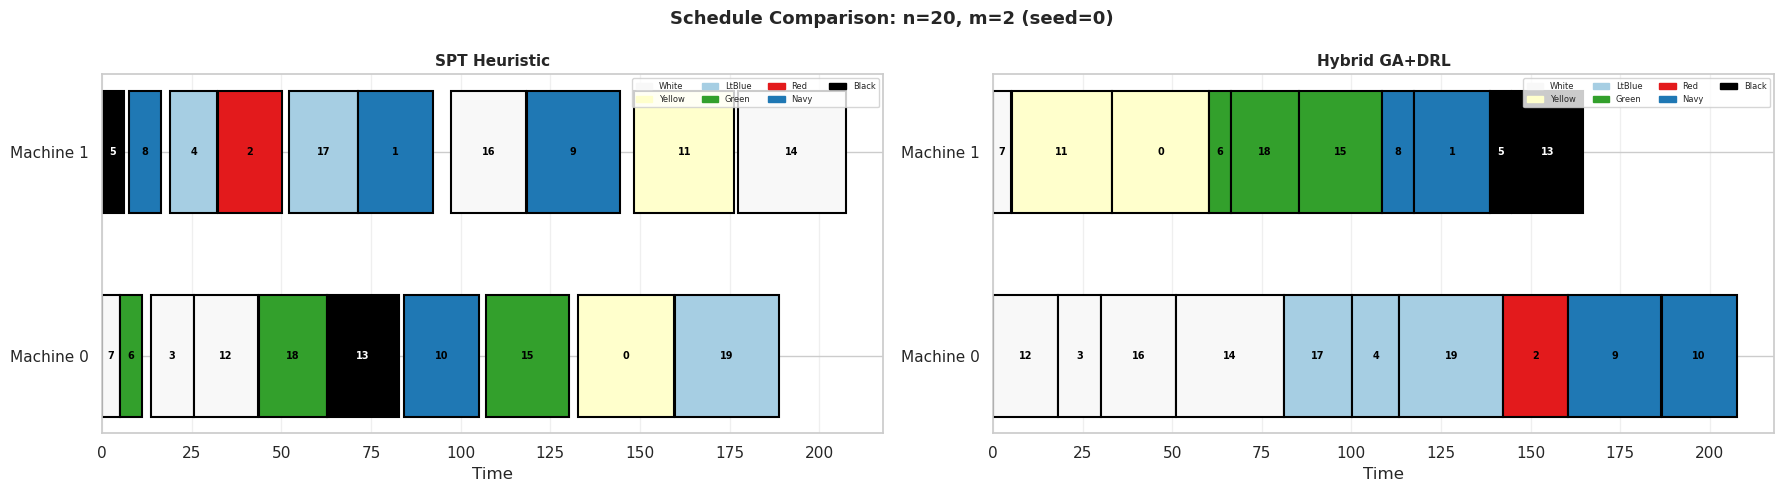

Saved: figures/06_gantt_comparison.png


In [3]:
def plot_gantt(sigma, instance, ax, title):
    """Plot a Gantt chart for a given schedule on the provided Axes."""
    m = instance["m"]
    proc = instance["proc_times"]
    setup_t = instance["setup_time"]
    colours = instance["colour_ids"]

    # Build job start/end times per machine
    machine_jobs = []  # list of (job, start, end, colour) for each machine
    for k, seq in enumerate(sigma):
        t = 0.0
        for idx, job in enumerate(seq):
            if idx > 0:
                prev = seq[idx - 1]
                t += float(setup_t[prev][job])
            start = t
            t += float(proc[job])
            end = t
            machine_jobs.append((k, job, start, end, int(colours[job])))

    palette = ['#f8f8f8','#ffffcc','#a6cee3','#33a02c','#e31a1c','#1f78b4','#000000']
    colour_map = {i: palette[i] for i in range(len(palette))}
    labels = ['White','Yellow','LtBlue','Green','Red','Navy','Black']

    for k, job, start, end, cid in machine_jobs:
        ax.barh(k, end - start, left=start, height=0.6,
                color=colour_map[cid], edgecolor='black', linewidth=1.5)
        ax.text((start + end) / 2, k, str(job),
                ha='center', va='center', fontsize=7, fontweight='bold',
                color='black' if cid < 6 else 'white')

    ax.set_yticks(range(m))
    ax.set_yticklabels([f"Machine {k}" for k in range(m)])
    ax.set_xlabel("Time")
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    # Legend
    patches = [mpatches.Patch(color=colour_map[i], label=labels[i]) for i in range(len(palette))]
    ax.legend(handles=patches, loc='upper right', fontsize=6, ncol=4)


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_gantt(spt_sigma, inst, axes[0], "SPT Heuristic")
if hybrid_result is not None:
    hybrid_sigma = hybrid_result.get("best_sigma", None)
    if hybrid_sigma is None:
        # get_best_result() doesn't return sigma, re-decode from ga_env
        from src.ga import decode_chromosome
        hybrid_sigma = decode_chromosome(
            list(ga_result["hof"][0]), inst["m"]
        ) if "hof" in ga_result else None
    plot_gantt(hybrid_sigma, inst, axes[1], "Hybrid GA+DRL")
else:
    axes[1].text(0.5, 0.5, "No hybrid result available", ha='center', va='center', transform=axes[1].transAxes)

fig.suptitle(f"Schedule Comparison: n={inst['n']}, m={inst['m']} (seed=0)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/06_gantt_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: figures/06_gantt_comparison.png")

## 3. Convergence Plot

Min fitness over generations for GA vs Hybrid (single representative run, seed=0).

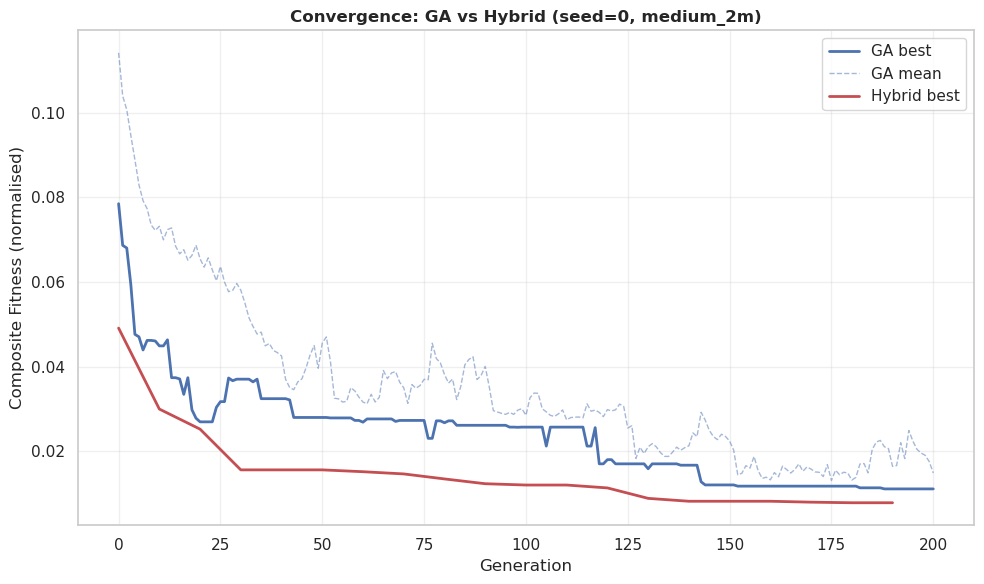

Saved: figures/06_convergence.png


In [4]:
if ga_result is not None:
    fig, ax = plt.subplots(figsize=(10, 6))

    # GA convergence from logbook
    logbook = ga_result["logbook"]
    gen = logbook.select("gen")
    gen_min = logbook.select("min")
    gen_mean = logbook.select("mean")
    ax.plot(gen, gen_min, 'b-', linewidth=2, label='GA best')
    ax.plot(gen, gen_mean, 'b--', alpha=0.5, linewidth=1, label='GA mean')

    # Hybrid: run with action logging for convergence
    if hybrid_result is not None:
        # Rerun hybrid with action logging to track convergence
        from src.ga_env import GAHyperHeuristicEnv
        env_conv = GAHyperHeuristicEnv(inst)
        obs, _ = env_conv.reset(seed=0)
        hybrid_best = []
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = env_conv.step(int(action))
            hybrid_best.append(float(env_conv.hof[0].fitness.values[0]))
            done = terminated or truncated
        # Expand step-level to generation-level
        hybrid_gens = np.linspace(0, len(gen)-1, len(hybrid_best))
        ax.plot([i * 10 for i in range(len(hybrid_best))], hybrid_best,
                'r-', linewidth=2, label='Hybrid best')

    ax.set_xlabel("Generation")
    ax.set_ylabel("Composite Fitness (normalised)")
    ax.set_title("Convergence: GA vs Hybrid (seed=0, medium_2m)", fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(root, "figures/06_convergence.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figures/06_convergence.png")
else:
    print("No GA result available.")

## Summary

- **Gantt chart** (figures/06_gantt_comparison.png): side-by-side SPT vs Hybrid schedules with colour-coded jobs
- **Convergence plot** (figures/06_convergence.png): GA vs Hybrid fitness over generations

Both saved at 150 DPI for dissertation inclusion.